# Null vectors & the BT→TIB extraction in TIB realizations

Interactive version of `scripts/compare_null_vectors.py`.

**Part 1 — what null vectors control.** Canonical vs random null vectors both give a valid, balanced TIB system (`A A* + B B* = I`); they differ only in the *input-coupling structure* — i.e. *which* transfer function gets realized.

**Part 2 — fitting a target.** With a known cross-coupled target we compare how well different null-vector choices and BT→TIB extractions reproduce its impulse response, and show that `tib_from_state_space` is the correct extraction (while `extract_poles_and_nullvecs_from_bt` is not).

In [1]:
%matplotlib inline
import sys, os

# make the ga package importable regardless of where the notebook is launched
try:
    import ga  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt

from ga.filters.tib import (
    poles_chebyshev_roots,
    mimo_standard_null_vectors,
    null_basis_realization,
    mimo_poles_to_ir,
    krylov_basis,
)
from ga.reducers.balanced_truncation import (
    balanced_truncation,
    extract_poles_and_nullvecs_from_bt,
    bt_impulse_response,
    tib_from_state_space,
)

P     = 12   # number of poles / states
Q     = 6    # number of input channels (q > 5: the MIMO regime)
P_OUT = 4    # number of outputs (Part 2)
LAGS  = 40   # impulse-response length
SEED  = 0

## Part 1 — what does a null vector control?

Each `(pole λₖ, null vector vₖ)` pair is one decaying mode: `λₖ` is the decay rate, `vₖ` the input direction that excites it.

* **Canonical** null vectors (`mimo_standard_null_vectors`) assign mode `k` to a single channel `k % q` (round-robin) → block-sparse, channel-decoupled input coupling.
* **Random** unit vectors mix every channel into every mode → dense coupling.

Both are valid, input-balanced TIB systems.

In [2]:
def canonical_null_vectors(p, q):
    """(q, p) null-vector matrix: mode k driven by channel k % q (round-robin)."""
    return mimo_standard_null_vectors(p, q).T          # (p, q) -> (q, p)

def random_null_vectors(p, q, seed=SEED):
    """(q, p) matrix of real unit null vectors, one per pole."""
    rng = np.random.default_rng(seed)
    v = rng.standard_normal((q, p))
    return v / np.linalg.norm(v, axis=0)

def tib_residual(sys):
    """max |A A* + B B* - I| -- ~0 for any unit null vectors."""
    A, B = sys.A(dense=True), sys.B(dense=True)
    resid = A @ A.conj().T + B @ B.conj().T - np.eye(A.shape[0])
    return float(np.max(np.abs(resid)))

def cross_channel_energy_fraction(ir, q):
    """Fraction of IR energy off a mode's assigned channel (C = I -> output k is
    state k; canonical assigns state k to channel k % q)."""
    p = ir.shape[0]
    assigned = np.arange(p) % q
    total = float(np.sum(np.abs(ir) ** 2))
    on = sum(float(np.sum(np.abs(ir[k, assigned[k], :]) ** 2)) for k in range(p))
    return (total - on) / total

def b_nonzeros(sys, tol=1e-10):
    return int(np.sum(np.abs(sys.B(dense=True)) > tol))

In [3]:
poles = poles_chebyshev_roots(P)      # real, decaying modes in (0, 1)
C_eye = np.eye(P)                     # outputs = states -> read per-mode coupling

cases = {
    "canonical": canonical_null_vectors(P, Q),
    "random":    random_null_vectors(P, Q),
}

systems, irs = {}, {}
print(f"TIB system: P={P} poles, Q={Q} input channels, {LAGS} lags\n")
print(f"{'case':<10} {'TIB resid':>12} {'B nnz':>8} {'B nnz max':>10} {'cross-chan E':>14}")
print("-" * 58)
for name, v in cases.items():
    sys = null_basis_realization(poles, v)
    ir = mimo_poles_to_ir(poles, v, C_eye, LAGS)       # (P, Q, LAGS)
    systems[name], irs[name] = sys, ir
    print(f"{name:<10} {tib_residual(sys):>12.2e} {b_nonzeros(sys):>8d} "
          f"{P * Q:>10d} {cross_channel_energy_fraction(ir, Q):>13.1%}")

TIB system: P=12 poles, Q=6 input channels, 40 lags

case          TIB resid    B nnz  B nnz max   cross-chan E
----------------------------------------------------------
canonical      2.22e-16       12         72          0.0%
random         5.55e-16       72         72         83.8%


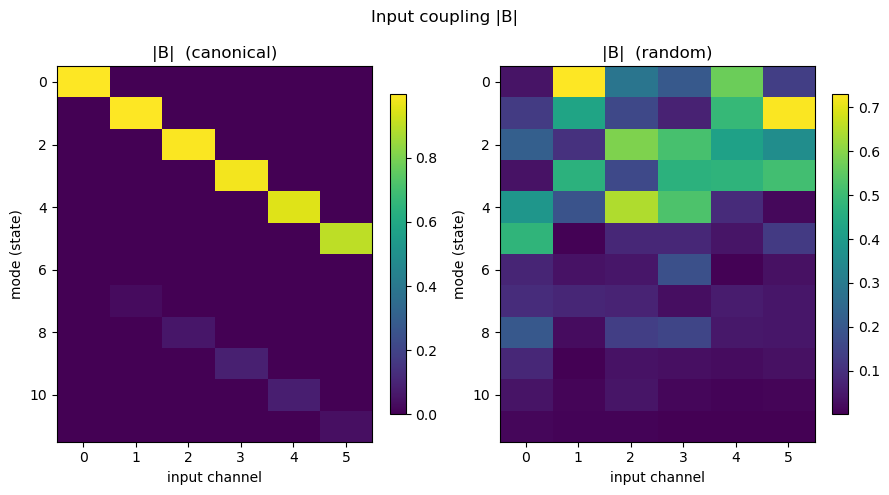

In [4]:
# Figure 1 -- input coupling |B|: canonical (round-robin) vs random (dense)
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax, name in zip(axes, systems):
    B = np.abs(systems[name].B(dense=True))
    im = ax.imshow(B, aspect="auto", cmap="viridis")
    ax.set_title(f"|B|  ({name})")
    ax.set_xlabel("input channel"); ax.set_ylabel("mode (state)")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Input coupling |B|")
fig.tight_layout()
plt.show()

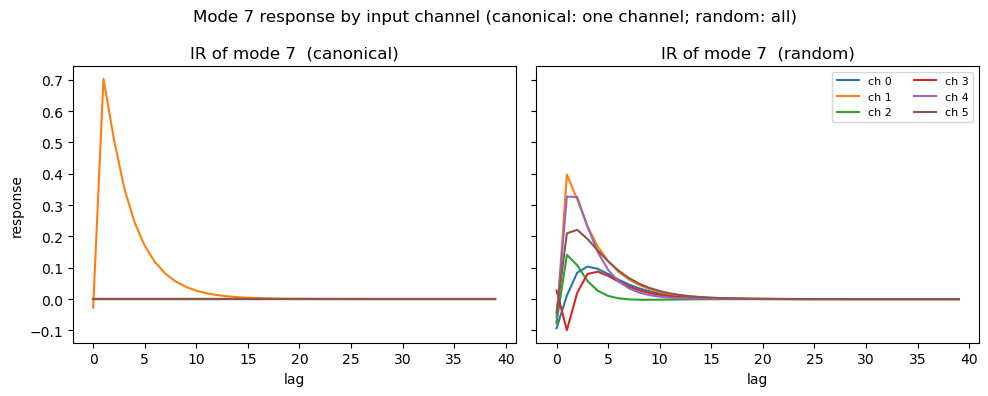

In [5]:
# Figure 2 -- response of one mode across all input channels
mode = Q + 1     # a mode assigned to channel 1 under the round-robin scheme
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, name in zip(axes, irs):
    for j in range(Q):
        ax.plot(irs[name][mode, j, :], label=f"ch {j}")
    ax.set_title(f"IR of mode {mode}  ({name})")
    ax.set_xlabel("lag")
axes[0].set_ylabel("response")
axes[1].legend(fontsize=8, ncol=2)
fig.suptitle(f"Mode {mode} response by input channel "
             f"(canonical: one channel; random: all)")
fig.tight_layout()
plt.show()

**Part 1 takeaway.** Both systems satisfy `A A* + B B* = I` to machine precision — the balance identity cannot tell them apart. Canonical `B` has one nonzero per mode (~0% cross-channel energy); random `B` is dense (~84% cross-channel). **The null-vector choice sets *which* system you realize, not its quality.**

## Part 2 — which null vectors / extraction reproduce a target?

Ground truth: an order-`P` TIB system with *cross-coupled* true null vectors and a random output matrix `C`; its impulse response is the "data". We compare two groups:

**References (what is achievable):**
* `oracle` — the true null vectors (target is exactly TIB-representable; also validates the least-squares `C` fit)
* `BT reduced` — `balanced_truncation`'s own reduced IR
* `corrected` — `tib_from_state_space` (input-balance + Schur): the correct BT→TIB path

**TIB null-vector choices (poles fixed, best-fit `C`):**
* `canonical`, `random`, and `fitted` (`extract_poles_and_nullvecs_from_bt`)

In [6]:
def fit_output_matrix(A, B, target_ir, lags):
    """Best-case IR for a given (A, B): least-squares output matrix C.

    IR is linear in C  (ir[o,j,t] = sum_s C[o,s] (A^t B)[s,j]), so the optimal
    C is a linear least-squares solve. Fitting C this way isolates the effect of
    the null vectors -- any residual error is due to (A, B)."""
    K = np.asarray(krylov_basis(A, B, lags), dtype=float)   # (P, Q, lags)
    M = K.reshape(A.shape[0], -1)                           # (P, Q*lags)
    Y = target_ir.reshape(target_ir.shape[0], -1)           # (P_OUT, Q*lags)
    C = np.linalg.lstsq(M.T, Y.T, rcond=None)[0].T          # (P_OUT, P)
    return (C @ M).reshape(target_ir.shape)

def rel_error(a, b):
    return float(np.linalg.norm(a - b) / max(np.linalg.norm(b), 1e-15))

In [7]:
rng = np.random.default_rng(7)
v_true = random_null_vectors(P, Q, seed=7)                  # true cross-coupled dirs
C_true = rng.standard_normal((P_OUT, P))
target_ir = mimo_poles_to_ir(poles, v_true, C_true, LAGS)   # (P_OUT, Q, LAGS)

# genesis-alpha BT -> TIB pipeline on the (known) full-order system
true_sys = null_basis_realization(poles, v_true)
result = balanced_truncation(true_sys.A(dense=True), true_sys.B(dense=True),
                             C_true, order=P)
poles_fit, nullvecs_fit = extract_poles_and_nullvecs_from_bt(result)

def tib_fit(v):
    sys = null_basis_realization(poles, v)                  # poles fixed; vary v only
    return fit_output_matrix(sys.A(dense=True), sys.B(dense=True), target_ir, LAGS)

fit_irs = {"target": target_ir}

# --- references: what is achievable ---
fit_irs["oracle"] = tib_fit(v_true)
bt_ir = bt_impulse_response(result, LAGS)
corr_sys, transform = tib_from_state_space(result.A_r, result.B_r)   # the fix
corr_K = np.asarray(krylov_basis(corr_sys.A(dense=True),
                                 corr_sys.B(dense=True), LAGS))
corr_ir = np.tensordot(result.C_r @ transform, corr_K, (-1, 0))
fit_irs["corrected"] = corr_ir

print(f"BT pole recovery (sorted, rel err): "
      f"{rel_error(np.sort(poles_fit), np.sort(poles)):.2e}\n")
print(f"{'reference':<26} {'IR rel err':>12}")
print("-" * 40)
print(f"{'oracle (true v)':<26} {rel_error(fit_irs['oracle'], target_ir):>12.2e}")
print(f"{'BT reduced (direct)':<26} {rel_error(bt_ir, target_ir):>12.2e}")
print(f"{'corrected (tib_from_ss)':<26} {rel_error(corr_ir, target_ir):>12.2e}")

# --- TIB null-vector choices (best-fit C) ---
nv_cases = {
    "canonical":           canonical_null_vectors(P, Q),
    "random":              random_null_vectors(P, Q, seed=99),
    "fitted (BT extract)": nullvecs_fit.T,
}
print(f"\n{'TIB null vectors':<22} {'IR fit rel err (best C)':>24}")
print("-" * 48)
for name, v in nv_cases.items():
    fit_irs[name.split()[0]] = tib_fit(v)
    print(f"{name:<22} {rel_error(fit_irs[name.split()[0]], target_ir):>24.2e}")

BT pole recovery (sorted, rel err): 4.29e-15

reference                    IR rel err
----------------------------------------
oracle (true v)                1.18e-15
BT reduced (direct)            9.93e-15
corrected (tib_from_ss)        1.34e-14

TIB null vectors        IR fit rel err (best C)
------------------------------------------------
canonical                              3.47e-01
random                                 5.05e-01
fitted (BT extract)                    5.25e-01


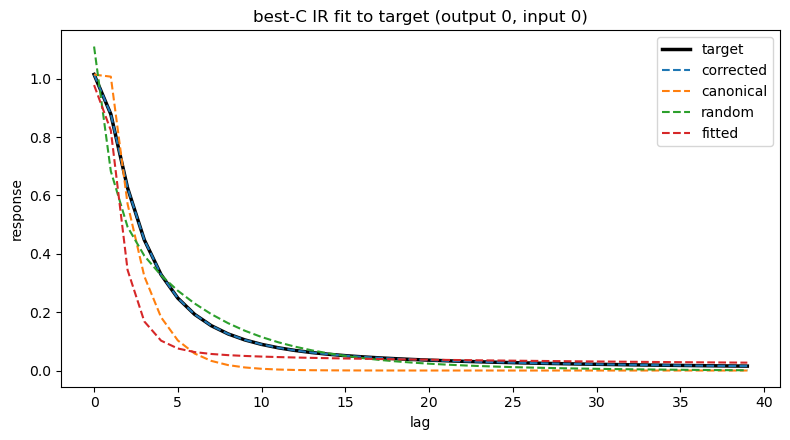

In [8]:
# Figure 3 -- best-C IR fit to the target for one (output, input) pair
out, inp = 0, 0
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(fit_irs["target"][out, inp, :], "k-", lw=2.5, label="target")
for name in ("corrected", "canonical", "random", "fitted"):
    ax.plot(fit_irs[name][out, inp, :], "--", label=name)
ax.set_title(f"best-C IR fit to target (output {out}, input {inp})")
ax.set_xlabel("lag"); ax.set_ylabel("response"); ax.legend()
fig.tight_layout()
plt.show()

**Part 2 takeaway.**

* `oracle ≈ 0` and `BT reduced ≈ 0` → the target is exactly representable and BT reproduces it: the data is perfectly fittable.
* `corrected (tib_from_state_space) ≈ 0` → re-coordinating the BT system into TIB form (input-balance + orthogonal Schur) recovers the target exactly. **This is the right BT→TIB path** (and it handles complex poles too — they appear as 2×2 real diagonal blocks).
* `canonical`, `random`, `fitted` are all far off, and **`fitted` is no better than guessing**: `extract_poles_and_nullvecs_from_bt` returns the orthonormalized `yₖ` of a Schur (not input-balanced) realization, so feeding them to `null_basis_realization` realizes the *wrong* transfer function.

➡️ **Use `tib_from_state_space`, not `extract_poles_and_nullvecs_from_bt`.**